In [1]:
import uproot
import matplotlib
import pandas as pd
import numpy as np
from tqdm import tqdm
import dask.dataframe as dd
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import glob
import boost_histogram as bh
import os
import re
from multihist import Histdd
from tqdm import tqdm
from utils import activity

### Helper Functions

In [2]:
#############################
# Energy Resolution Function
#############################

# Function taken from from XENON1T 
def energy_res(energy, a_res=0.317, b_res=1.7):
    resolution = a_res*np.sqrt(energy)+b_res*10**-3*energy
    e_smeared = np.random.normal(energy,resolution)
    return e_smeared

In [26]:
#############################
# Activity/Isotope/Vol Dict
#############################
act_dict = activity

#############################
# Volume Mass Dict
#############################

mass_dict = {'PMT': 2368, 'Sapphire': 250, 'Teflon':300, 'Cryostat': 12900, 'Copper': 505}

In [27]:
# Assumed this number is tracked. Best to get info directly from files later.
num_primaries_perfile = {'PMT': 250000, 'Teflon': 250000, 'Cryostat': 250000, 'Sapphire': 250000, 'Copper': 250000}

In [28]:
#Combine Mass and Activity dicts to determine Scaling Factors
scale_dict = {}
for vol_key, volume in act_dict.items():
    volume_scale = {}
    for iso_key, isotope in volume.items():
        if iso_key == 'Unit':
            continue
        elif not isinstance(act_dict[vol_key][iso_key], str):
            if (act_dict[vol_key][iso_key])>0:
                scale_factor = num_primaries_perfile[vol_key]/(mass_dict[vol_key]*act_dict[vol_key][iso_key]*10e-6)
            else:
                scale_factor=0
        volume_scale[iso_key] = scale_factor
        #print(scale_factor)
    scale_dict[vol_key] = volume_scale

In [29]:
#############################
# Selection Functions
#############################
def select_ss_ms_events(df):
    # For each runid, for each eventid, select clusters with only one cluster_id (single scatter)
    ss_events = df[df['nclusters'] == 1]
    ms_events = df[df['nclusters'] > 1]
    
    return ss_events, ms_events

def select_events_in_energy_range(df, energy_range=(4, 50)):
    # energy ROI cut
    # NR: (4, 50) keV -> ER: (1, 12) keV
    return df[df["edep"].between(*energy_range)]

# and occur inside the fiducial volume and within the energy ROI
def select_events_in_roi(df, fv_z, fv_radius, energy_range=(4, 50)):
    # Apply fiducial volume cut
    events_fv = df[df["zp"].between(*fv_z) & (df["xp"]**2 + df["yp"]**2 <= fv_radius**2)]
    events_roi = select_events_in_energy_range(events_fv, energy_range=energy_range)
    return events_roi

### Raw Distributions

/storage/xenon/nadavh/hermeticTPC/BigStats_01/PMT/U238/PMT_U238_*_s10mm.parquet


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1199/1199 [00:29<00:00, 40.90it/s]


1579.0
/storage/xenon/nadavh/hermeticTPC/BigStats_01/Cryostat/U238/Cryostat_U238_*_s10mm.parquet


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:18<00:00, 54.84it/s]


2499.9970703125
/storage/xenon/nadavh/hermeticTPC/BigStats_01/Teflon/U238/Teflon_U238_*_s10mm.parquet


...

1465.0
/storage/xenon/nadavh/hermeticTPC/BigStats_01/Copper/U238/Copper_U238_*_s10mm.parquet


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 398/398 [00:16<00:00, 24.78it/s]


1364.9830322265625
/storage/xenon/nadavh/hermeticTPC/BigStats_01/Sapphire/U238/Sapphire_U238_*_s10mm.parquet


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:33<00:00, 29.50it/s]


1460.5


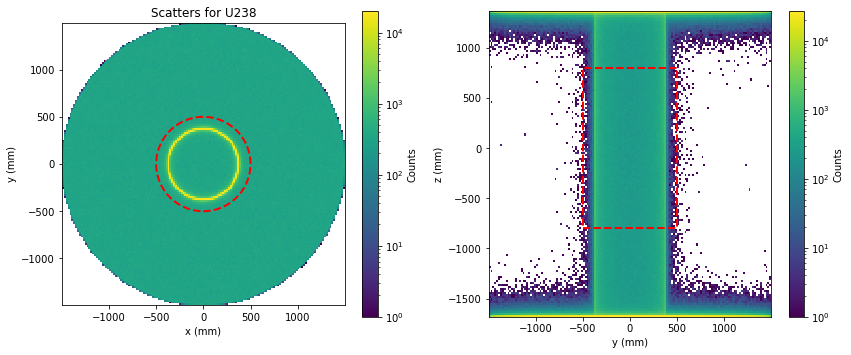

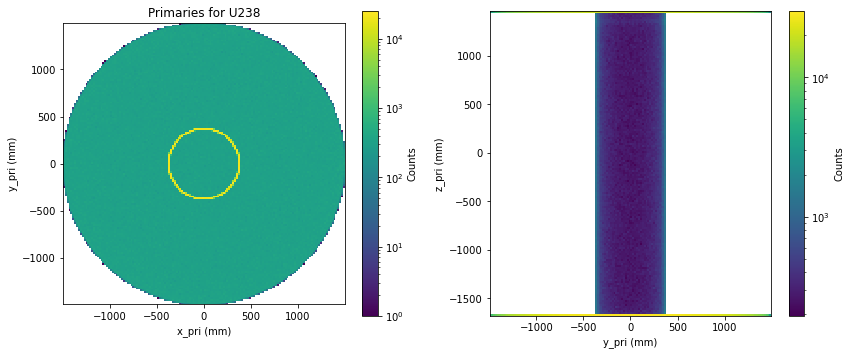

1175897


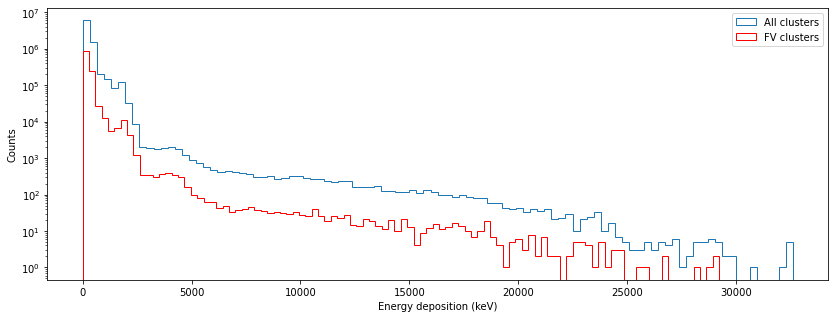

/storage/xenon/nadavh/hermeticTPC/BigStats_01/PMT/Th232/PMT_Th232_*_s10mm.parquet


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1200/1200 [00:28<00:00, 41.63it/s]


1579.0
/storage/xenon/nadavh/hermeticTPC/BigStats_01/Cryostat/Th232/Cryostat_Th232_*_s10mm.parquet


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:15<00:00, 64.28it/s]


2499.994873046875
/storage/xenon/nadavh/hermeticTPC/BigStats_01/Teflon/Th232/Teflon_Th232_*_s10mm.parquet


...

1465.0
/storage/xenon/nadavh/hermeticTPC/BigStats_01/Copper/Th232/Copper_Th232_*_s10mm.parquet


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:14<00:00, 27.83it/s]


1364.98193359375
/storage/xenon/nadavh/hermeticTPC/BigStats_01/Sapphire/Th232/Sapphire_Th232_*_s10mm.parquet


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:33<00:00, 30.23it/s]


1460.5


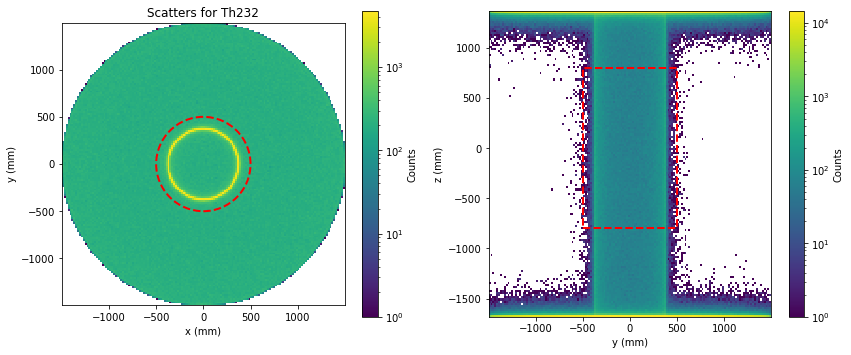

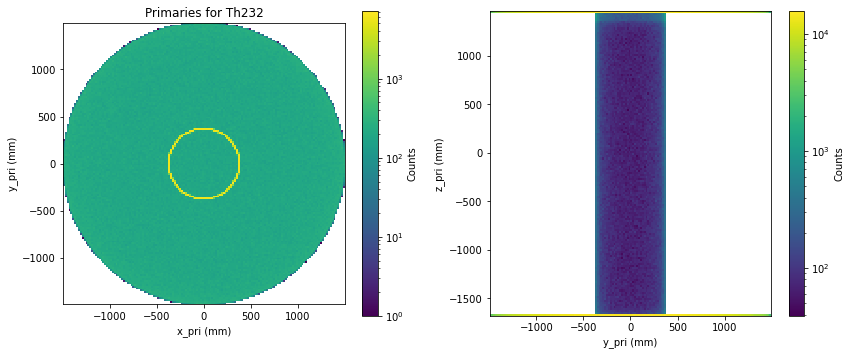

305824


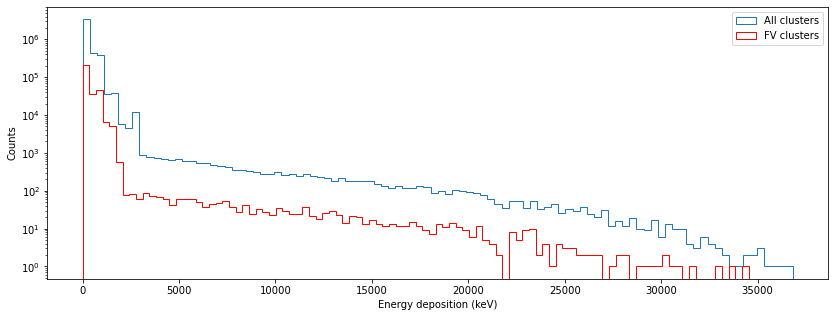

/storage/xenon/nadavh/hermeticTPC/BigStats_01/PMT/Co60/PMT_Co60_*_s10mm.parquet


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1198/1198 [00:23<00:00, 51.38it/s]


1579.0
/storage/xenon/nadavh/hermeticTPC/BigStats_01/Cryostat/Co60/Cryostat_Co60_*_s10mm.parquet


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 73.54it/s]


2499.998046875
/storage/xenon/nadavh/hermeticTPC/BigStats_01/Teflon/Co60/Teflon_Co60_*_s10mm.parquet


...

1465.0
/storage/xenon/nadavh/hermeticTPC/BigStats_01/Copper/Co60/Copper_Co60_*_s10mm.parquet


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:25<00:00, 15.78it/s]


1365.0
/storage/xenon/nadavh/hermeticTPC/BigStats_01/Sapphire/Co60/Sapphire_Co60_*_s10mm.parquet


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:27<00:00, 36.18it/s]


1460.5


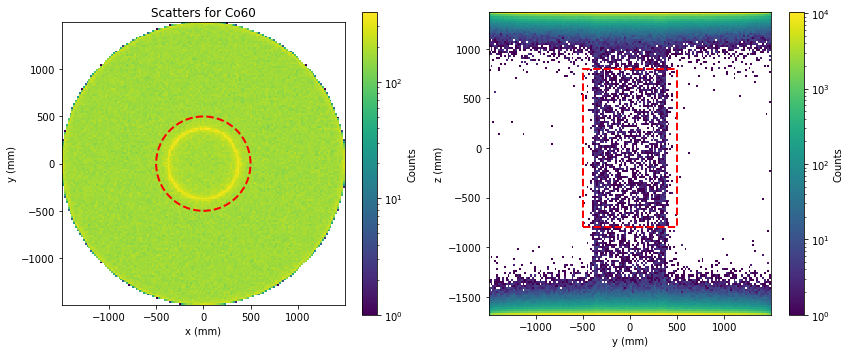

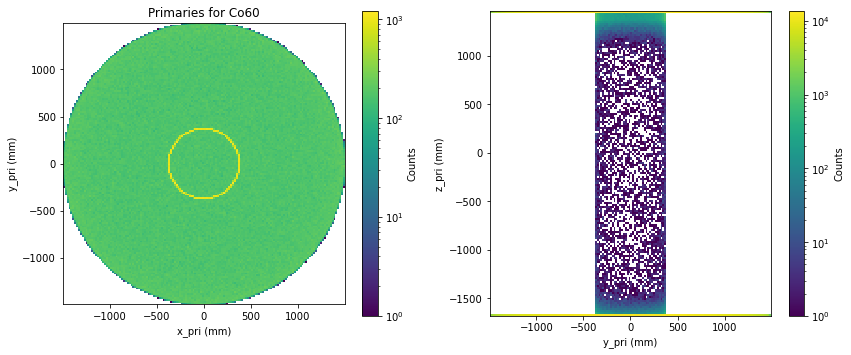

3783


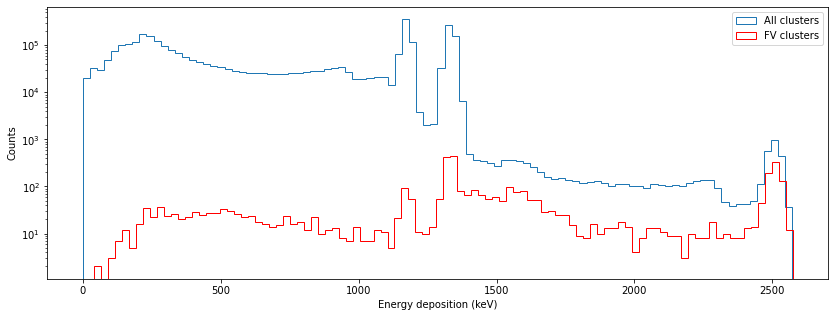

In [8]:
file_prefix = ''
fv_x = 500  # mm
fv_z = (-800, 800)  # mm
max_index=100

for isotope in ['U238', 'Th232', 'Co60']:
    for key, volume in act_dict.items():
        all_dfs = []
    
        # Search for all files matching the pattern for this key + isotope
        file_pattern = f'/storage/xenon/nadavh/hermeticTPC/BigStats_01/{key}/{isotope}/{key}_{isotope}_*_s10mm.parquet'
        matched_files_n = sorted(glob.glob(file_pattern))
        file_pattern = f'/storage/xenon/jacquesp/hermeticTPC/BigStats_01/{key}/{isotope}/{key}_{isotope}_*_s10mm.parquet'
        matched_files_j = sorted(glob.glob(file_pattern))
        matched_files = np.concatenate([matched_files_j,matched_files_n])
        
        for filepath in tqdm(matched_files):
            filename = os.path.basename(filepath)
    
            # Use regex to extract serial number (handles zero-padding)
            match = re.match(rf'{re.escape(file_prefix)}{re.escape(key)}_{re.escape(isotope)}_(\d+)\_s10mm.parquet', filename)
            if match:
                serial_num = int(match.group(1))
                if serial_num > max_index:
                    continue
    
                # Load and collect DataFrame
                try:
                    iso_vol_df = pd.read_parquet(filepath)

                    #Find Single Scatters
                    iso_vol_df = iso_vol_df[iso_vol_df['nclusters']==1]
                    all_dfs.append(iso_vol_df)
                except:
                    continue
                
            else:
                print(f"Skipping file (name format doesn't match): {filename}")
    
        # Concatenate all matching DataFrames
        if not all_dfs:
            print(f"No files found for key {key}, isotope {isotope}")
            continue

        file_loaded_counter = len(all_dfs)
        fuse_data = pd.concat(all_dfs, ignore_index=True)
    
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    hxy = ax1.hist2d(fuse_data["xp"], fuse_data["yp"], bins=150, norm=matplotlib.colors.LogNorm())
    ax1.set_title(f"Scatters for {isotope}")
    ax1.set_xlabel("x (mm)")
    ax1.set_ylabel("y (mm)")
    ax1.set_aspect('equal', adjustable='box')

    hyz = ax2.hist2d(fuse_data["yp"], fuse_data["zp"], bins=150, norm=matplotlib.colors.LogNorm())
    #ax2.set_title(f"Fuse Cluster for {key}")
    ax2.set_xlabel("y (mm)")
    ax2.set_ylabel("z (mm)")
    #ax2.set_aspect('equal', adjustable='box')

    # make a box for the fiducial volume
    ax1.add_patch(plt.Circle((0, 0), fv_x, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))
    ax2.add_patch(plt.Rectangle((-fv_x, fv_z[0]), 2*fv_x, 2*fv_z[1], color='red', fill=False, linestyle='--', linewidth=2))

    fig.colorbar(hxy[3], label="Counts")
    fig.colorbar(hyz[3], label="Counts")
    fig.tight_layout()
    plt.show()


    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    hxy = ax1.hist2d(fuse_data["xp_pri"], fuse_data["yp_pri"], bins=150, norm=matplotlib.colors.LogNorm())
    ax1.set_title(f"Primaries for {isotope}")
    ax1.set_xlabel("x_pri (mm)")
    ax1.set_ylabel("y_pri (mm)")
    ax1.set_aspect('equal', adjustable='box')

    hyz = ax2.hist2d(fuse_data["yp_pri"], fuse_data["zp_pri"], bins=150, norm=matplotlib.colors.LogNorm())
    #ax2.set_title(f"Fuse Cluster for {key}")
    ax2.set_xlabel("y_pri (mm)")
    ax2.set_ylabel("z_pri (mm)")
    #ax2.set_aspect('equal', adjustable='box')

    fig.colorbar(hxy[3], label="Counts")
    fig.colorbar(hyz[3], label="Counts")
    fig.tight_layout()

    plt.show()


    fig = plt.figure(figsize=(14,5))
    plt.hist(energy_res(fuse_data["edep"], 0.317, 1.7), bins=100, histtype='step', label='All clusters')

    data_fv = energy_res(fuse_data[fuse_data["zp"].between(*fv_z) & (fuse_data["xp"]**2 + fuse_data["yp"]**2 <= fv_x**2)]["edep"], 0.317, 1.7)
    print(len(data_fv))
    plt.hist(data_fv, bins=100, histtype='step', label='FV clusters', color='red')

    plt.legend()

    plt.xlabel("Energy deposition (keV)")
    plt.ylabel("Counts")
    plt.yscale("log")

    plt.show()

### Rate Plots

In [171]:
LXe = {
    "density": 2.862, # g/cm3
    "temperature": 177.05, # K
    "pressure": 1.5 # bar
}

TPC_dimensions = {
    "radius": 1500, # mm
    "top": 1365, # mm
    "bottom": -1682, # mm
}
TPC_center = [0, 0, TPC_dimensions["top"]-(TPC_dimensions["top"] - TPC_dimensions["bottom"]) / 2]

In [ ]:
file_prefix = ''

#Max Files
max_index=1500

#Scaling Settings
year = 3.154e7  #seconds
estimates = {}
fv_radius = TPC_dimensions['radius']
fv_z = [TPC_dimensions['bottom'], TPC_dimensions['top']]
height =(fv_z[1]-fv_z[0])
volume = height/10*np.pi*(fv_radius/10)**2
fv_mass = (volume*LXe['density'])/1e6
_erange = (2000, 3000)

energy_binning = np.linspace(2000, 3000, 101)
for isotope in ['U238', 'Th232', 'Co60', 'K40', 'Cs137']:
    background_hist = Histdd(bins=[energy_binning])
    binwidth = background_hist.bin_centers(0)[1]-background_hist.bin_centers(0)[0]
    errors=np.zeros_like(background_hist.bin_centers(0))
    for key, volume in act_dict.items():
        all_dfs = []
    
        # Search for all files matching the pattern for this key + isotope
        #file_pattern = f'/storage/xenon/jacquesp/hermeticTPC/{key}_{isotope}_*.parquet'
        file_pattern = f'/storage/xenon/nadavh/hermeticTPC/BigStats_01/{key}/{isotope}/{key}_{isotope}_*_s10mm.parquet'
        matched_files_n = sorted(glob.glob(file_pattern))
        file_pattern = f'/storage/xenon/jacquesp/hermeticTPC/BigStats_01/{key}/{isotope}/{key}_{isotope}_*_s10mm.parquet'
        matched_files_j = sorted(glob.glob(file_pattern))
        matched_files = np.concatenate([matched_files_j,matched_files_n])
        
        for filepath in tqdm(matched_files):
            filename = os.path.basename(filepath)
    
            # Use regex to extract serial number (handles zero-padding)
            match = re.match(rf'{re.escape(file_prefix)}{re.escape(key)}_{re.escape(isotope)}_(\d+)\_s10mm.parquet', filename)
            if match:
                serial_num = int(match.group(1))
                if serial_num > max_index:
                    continue
    
                # Load and collect DataFrame
                try:
                    iso_vol_df = pd.read_parquet(filepath)

                    #Find Single Scatters
                    iso_vol_df = iso_vol_df[iso_vol_df['nclusters']==1]
                    all_dfs.append(iso_vol_df)
                except:
                    continue
                
            else:
                print(f"Skipping file (name format doesn't match): {filename}")
    
        # Concatenate all matching DataFrames
        if not all_dfs:
            print(f"No files found for key {key}, isotope {isotope}")
            continue
            
        file_loaded_counter = len(all_dfs)
        fuse_data = pd.concat(all_dfs, ignore_index=True)

        df_ss, df_ms = select_ss_ms_events(fuse_data)
        df_ss_energy = select_events_in_energy_range(df_ss, energy_range=(_erange))
        df_ss_roi = select_events_in_roi(df_ss_energy, fv_z, fv_radius, energy_range=(_erange))

        # Number of single scatter events total and in ROI
        e_ss_events = len(df_ss)
        e_ss_energy_events = len(df_ss_energy)
        e_ss_roi_events = len(df_ss_roi)

        # Scaling factor
        try:
            scale_factor = year / (scale_dict[key][isotope]* file_loaded_counter)
        except:
            print(isotope, key, scale_dict[key][isotope], file_loaded_counter, fv_mass)
            
        # Store histograms
        h_xy_ss = bh.Histogram(bh.axis.Regular(200, -1500, 1500), bh.axis.Regular(200, -1500, 1500))
        h_xy_ss.fill(df_ss["xp"], df_ss["yp"])
       
        h_rz_ss = bh.Histogram(bh.axis.Regular(200, 0, 1500), bh.axis.Regular(200, -1800, 1500))
        h_rz_ss.fill(np.sqrt(df_ss["xp"]**2 + df_ss["yp"]**2), df_ss["zp"])
        
        #Test 3D Histogram
        h_xy_ss_e = bh.Histogram(bh.axis.Regular(200, -1500, 1500), 
                                 bh.axis.Regular(200, -1500, 1500), 
                                 bh.axis.Regular(100, *_erange))
        h_xy_ss_e.fill(df_ss_energy["xp"], 
                       df_ss_energy["yp"], 
                       energy_res(df_ss_energy["edep"], 0.317, 1.7))
        
        h_rz_ss_e = bh.Histogram(bh.axis.Regular(200, 0, 1500), 
                                 bh.axis.Regular(200, -1800, 1500), 
                                 bh.axis.Regular(100, *_erange))
        h_rz_ss_e.fill(np.sqrt(df_ss_energy["xp"]**2 + df_ss_energy["yp"]**2), 
                       df_ss_energy["zp"], 
                       energy_res(df_ss_energy["edep"], 0.317, 1.7))

        _estimates = {key: {
            "scale_factor": scale_factor,
            "e_ss_events": e_ss_events,
            "e_ss_energy_events": e_ss_energy_events,
            "e_ss_roi_events": e_ss_roi_events,
            "h_xy_ss": h_xy_ss,
             #"h_xy_ss_energy": h_xy_ss_energy,
            #"h_xy_ss_roi": h_xy_ss_roi,
            "h_rz_ss": h_rz_ss,
            #"h_rz_ss_energy": h_rz_ss_energy,
            #"h_rz_ss_roi": h_rz_ss_roi,
            "h_rz_ss_e": h_rz_ss_e,
            "h_xy_ss_e": h_xy_ss_e,
        }}
        if isotope not in estimates:
            estimates[isotope] = {}
        estimates[isotope].update(_estimates)

 59%|███████████████████████████████████████████████████████████████████▉                                                | 703/1200 [02:51<02:38,  3.13it/s]

In [ ]:
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        print(f"Material: {material}, Isotope: {isotope}")
        print(f"  Total single scatter events: {iso_data['e_ss_events']}")
        print(f"  -> in energy ROI: {iso_data['e_ss_energy_events']}")
        print()

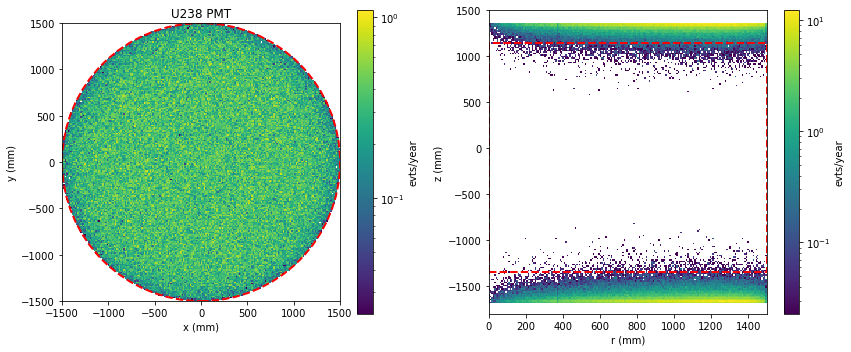

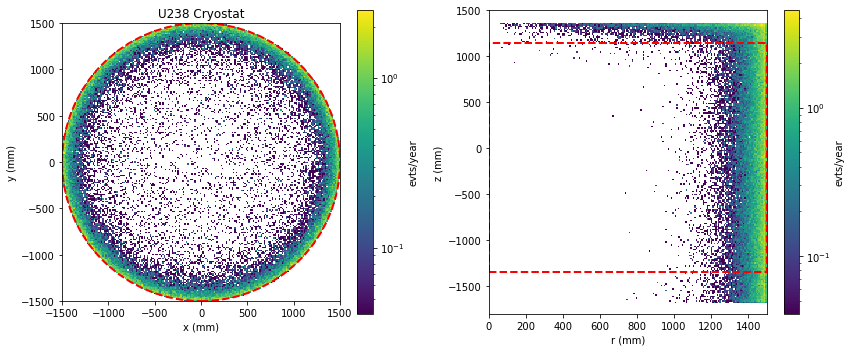

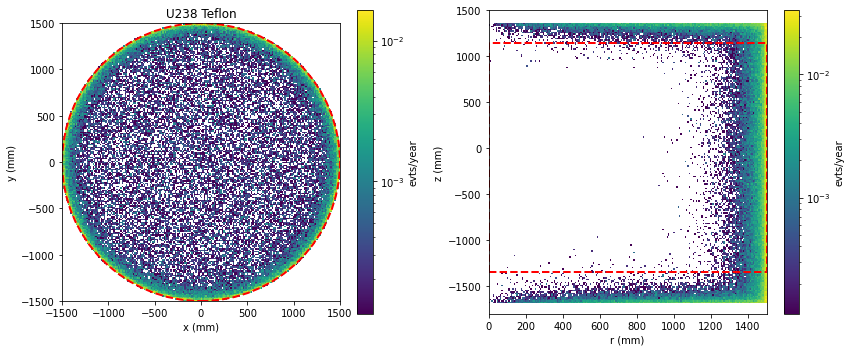

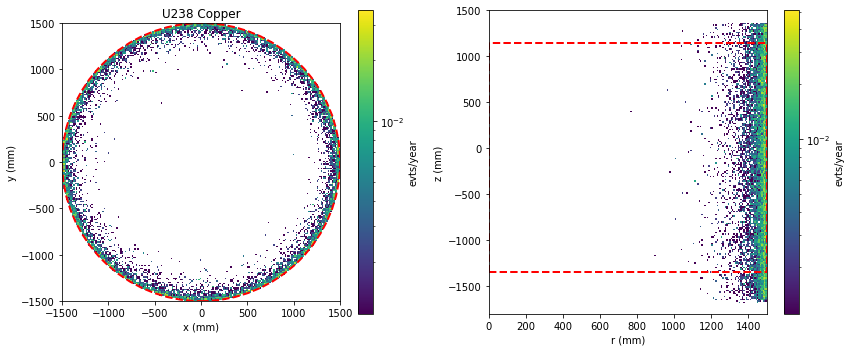

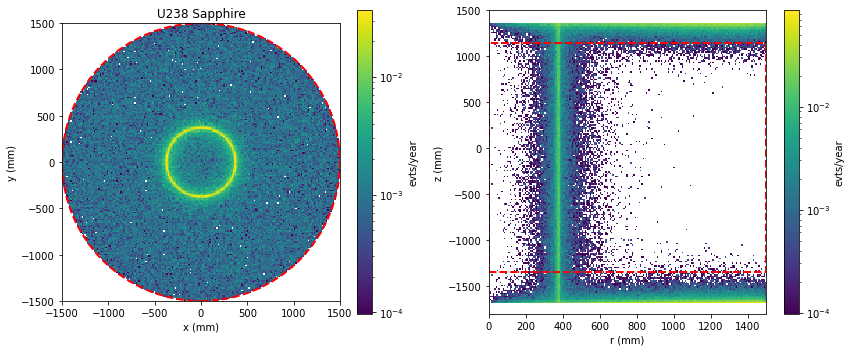

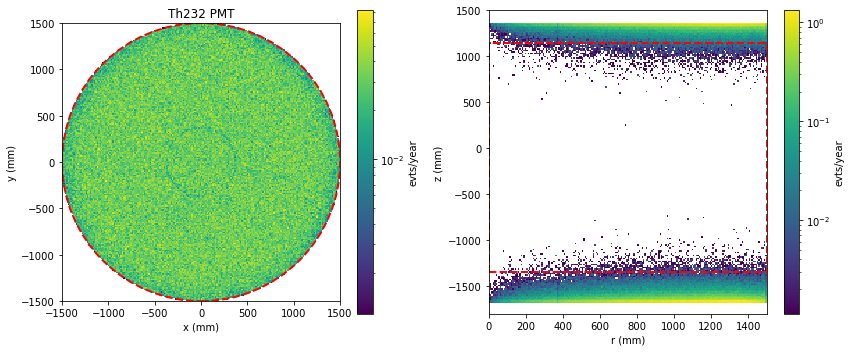

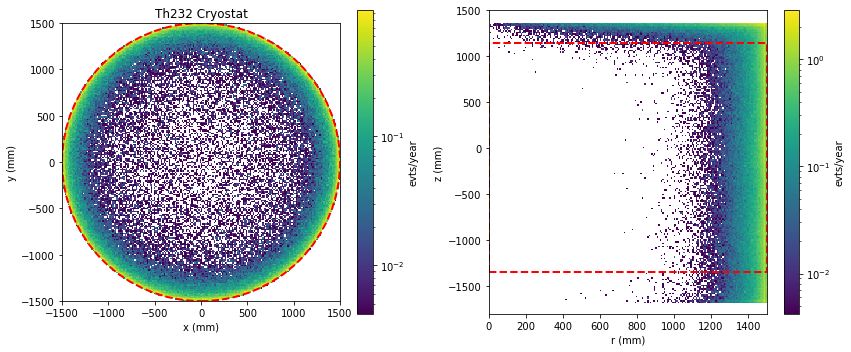

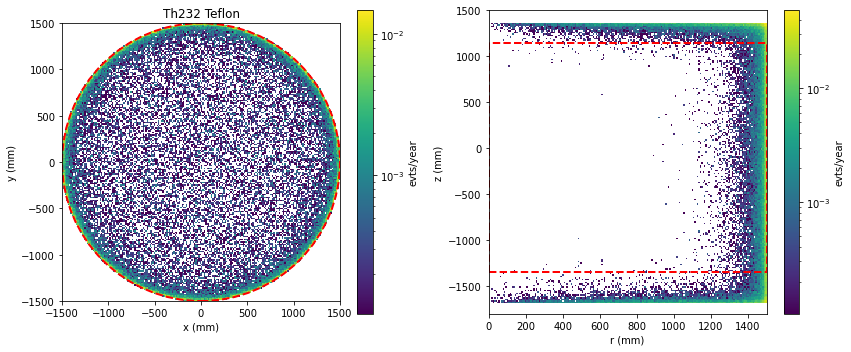

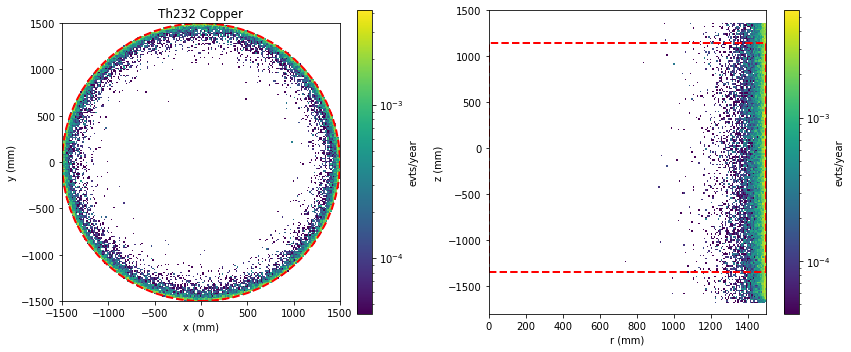

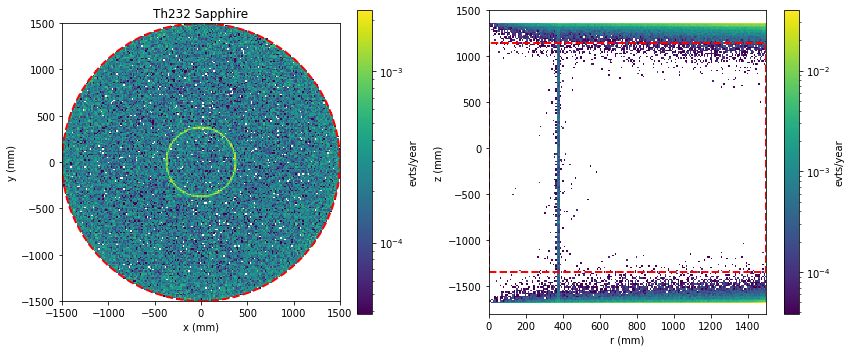

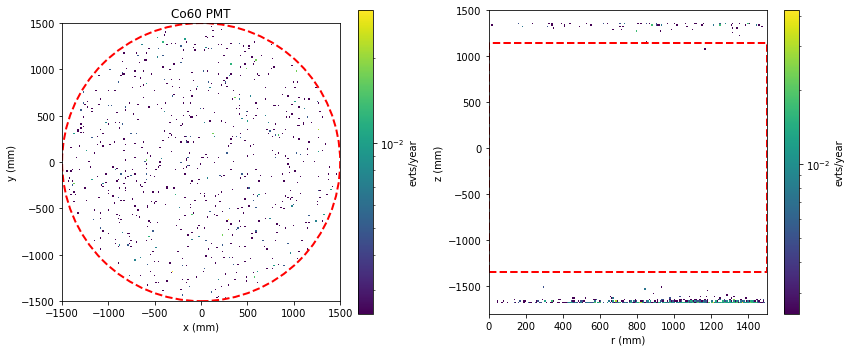

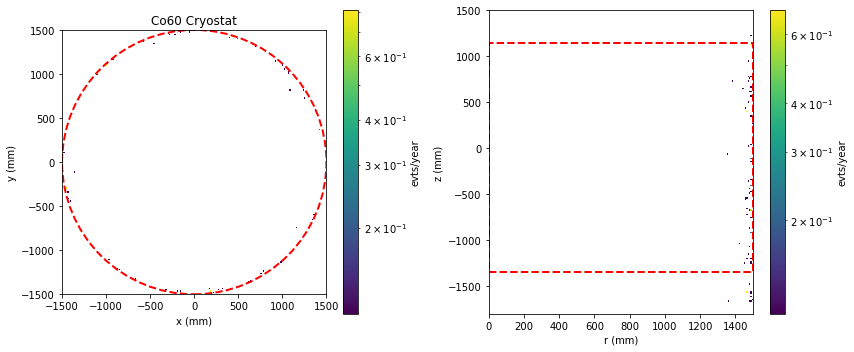

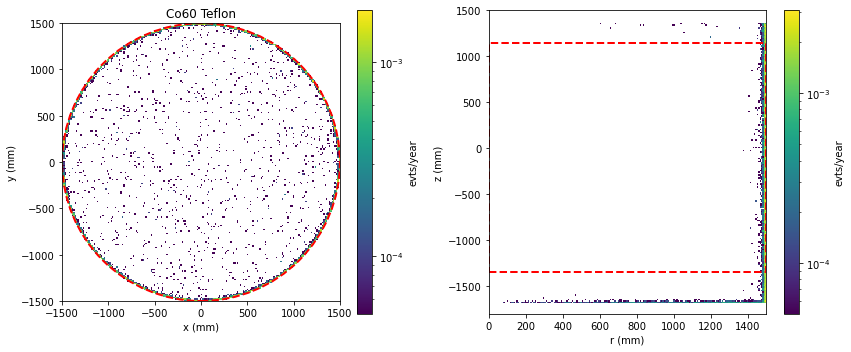

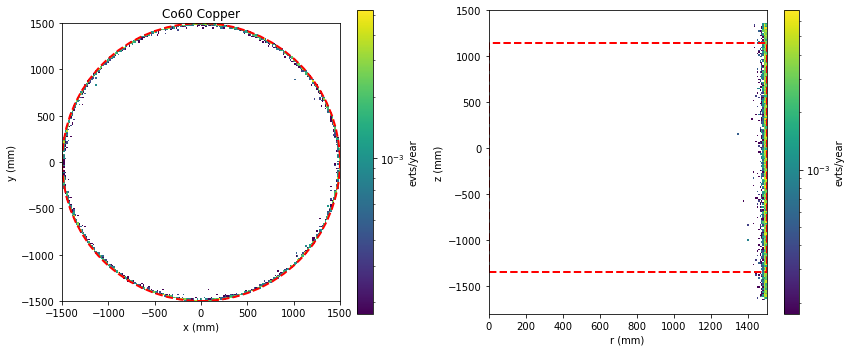

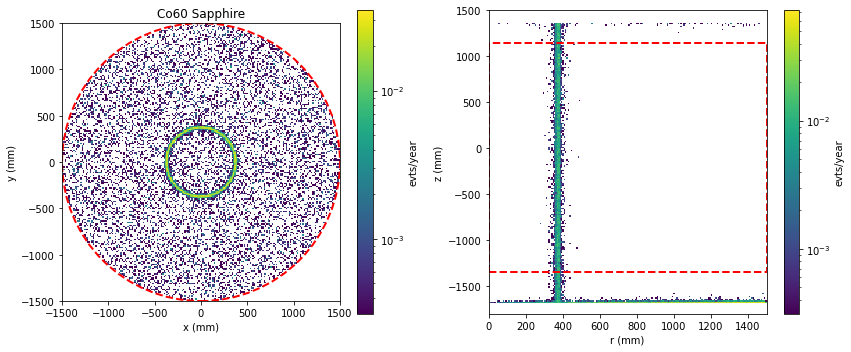

 Exception for K40  PMT
 Exception for K40  Teflon
 Exception for K40  Copper
 Exception for Cs137  PMT
 Exception for Cs137  Teflon
 Exception for Cs137  Copper
 Exception for Cs137  Sapphire


In [234]:
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        try:
            fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
            
            h_xy = iso_data["h_xy_ss_e"].project(0, 1)
            h_rz = iso_data["h_rz_ss_e"].project(0, 1)
            
            vals_xy = h_xy.values().T * iso_data["scale_factor"]
            vals_rz = h_rz.values().T * iso_data["scale_factor"]

            vals_xy = np.where(vals_xy > 0, vals_xy, np.nan)
            vals_rz = np.where(vals_rz > 0, vals_rz, np.nan)

            pcm1 = ax1.pcolormesh(
                *h_xy.axes.edges.T,
                vals_xy,
                norm=matplotlib.colors.LogNorm()
                )
            ax1.add_patch(plt.Circle((0, 0), fv_radius, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))

            ax1.set_title(f"{material} {isotope}")
            ax1.set_xlabel("x (mm)")
            ax1.set_ylabel("y (mm)")
            ax1.set_aspect('equal', adjustable='box')

            pcm2 = ax2.pcolormesh(
                *h_rz.axes.edges.T,
                vals_rz,
                norm=matplotlib.colors.LogNorm()
            )
            ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

            ax2.set_xlabel("r (mm)")
            ax2.set_ylabel("z (mm)")

            plt.colorbar(pcm1, label="evts/year")
            plt.colorbar(pcm2, label="evts/year")
            fig.tight_layout()
            plt.show()
        except ValueError:
            plt.close(fig)
            print (f" Exception for {material}  {isotope}")
            continue

### Sum All Histograms

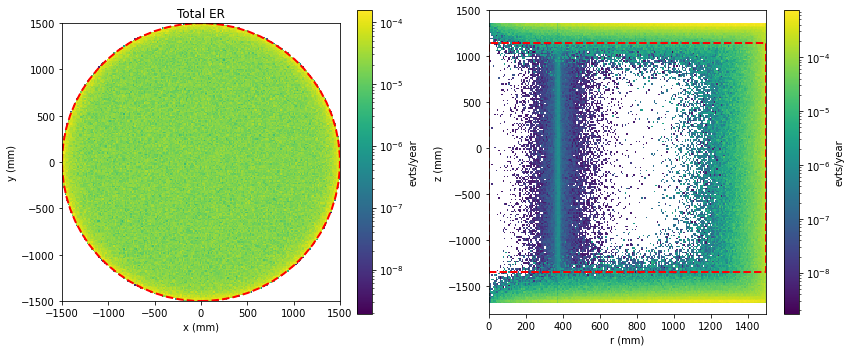

In [235]:
del h_xy_total
del h_rz_total
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        try:
            h_xy_total
        except NameError:
            h_xy_total = iso_data["h_xy_ss_e"].copy()
            h_xy_total.reset()
        try:
            h_rz_total
        except:
            h_rz_total = iso_data["h_rz_ss_e"].copy()
            h_rz_total.reset()
        
        h_xy_total += iso_data["h_xy_ss_e"]*iso_data['scale_factor']
        h_rz_total += iso_data["h_rz_ss_e"]*iso_data['scale_factor']

h_xy = h_xy_total.project(0, 1)
h_rz = h_rz_total.project(0, 1)

vals_xy = h_xy.values().T * iso_data["scale_factor"]
vals_rz = h_rz.values().T * iso_data["scale_factor"]

vals_xy = np.where(vals_xy > 0, vals_xy, np.nan)
vals_rz = np.where(vals_rz > 0, vals_rz, np.nan)        
        
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

pcm1 = ax1.pcolormesh(
    *h_xy.axes.edges.T,
    vals_xy,
    norm=matplotlib.colors.LogNorm()
)
ax1.add_patch(plt.Circle((0, 0), fv_radius, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))

ax1.set_title("Total ER")
ax1.set_xlabel("x (mm)")
ax1.set_ylabel("y (mm)")
ax1.set_aspect('equal', adjustable='box')

pcm2 = ax2.pcolormesh(
    *h_rz.axes.edges.T,
    vals_rz,
    norm=matplotlib.colors.LogNorm()
)
ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

ax2.set_xlabel("r (mm)")
ax2.set_ylabel("z (mm)")

plt.colorbar(pcm1, label="evts/year")
plt.colorbar(pcm2, label="evts/year")
fig.tight_layout()
plt.show()

### Mass Volume Normalization histogram

In [236]:
h_vol = h_rz.copy()
h_vol.reset()

r_edges = h_rz.axes[0].edges
z_edges = h_rz.axes[1].edges

dr2 = np.diff(r_edges**2)  
dz  = np.diff(z_edges)    
volumes = np.pi * dr2[:, np.newaxis] * dz

h_vol.view()[:] = volumes*LXe['density']/1e9 #(1e6  to convert to tonne)

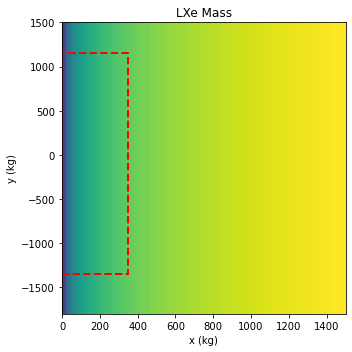

In [237]:
### To Do: Set Sapphire Bins to 0 mass
fig, (ax2) = plt.subplots(nrows=1, ncols=1, figsize=(5,5))

pcm1 = ax2.pcolormesh(*h_vol.axes.edges.T, h_vol.values().T, norm=matplotlib.colors.LogNorm())
ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_r, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

ax2.set_title("LXe Mass")
ax2.set_xlabel("R (cm)")
ax2.set_ylabel("Z (cm)")

plt.colorbar(pcm2, label="mass")
fig.tight_layout()
plt.show()

#### Xe136 0v2B Peak

In [239]:
N_A = 6.02214076e23          # 1/mol
M_XE136 = 135.907214484      # g/mol
Qbb =  2457.8

def expected_0vbb_events(
    half_life_yr,
    livetime_yr =1,
    mass_kg = 1000, 
    abundance_136=0.90,
    efficiency=1.0,
):
    """
    Expected number of Xe-136 0νββ decays observed.

    Parameters
    ----------
    half_life_yr : float or array-like
        Assumed 0νββ half-life in years.
    mass_kg : float
        Total xenon mass in kg.
    livetime_yr : float
        Live time in years.
    abundance_136 : float
        Fraction of Xe mass that is Xe-136.
        Example: 0.90 for 90% enrichment.
    efficiency : float
        Total signal efficiency, including containment, selection, ROI, etc.

    Returns
    -------
    float or np.ndarray
        Expected number of observed events.
    """
    mass_g = mass_kg * 1e3
    n_atoms = (mass_g * abundance_136 / M_XE136) * N_A
    return np.log(2) * n_atoms * livetime_yr * efficiency / half_life_yr


xe136_sample = energy_res(np.ones(10000)*Qbb, 0.317, 1.7)

### Normalize Total Histogram

In [243]:
h_rz_norm = h_rz/h_vol
fv_r = 350
fv_z = (-1250, 1050)
fv_mass = h_vol[
    :bh.loc(fv_r):sum,
    bh.loc(fv_z[0]):bh.loc(fv_z[1]):sum
]

In [244]:
### Calculate error bars
h_xy_total_var = None
h_rz_total_var = None

for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        if h_xy_total_var is None:
            h_xy_total_var = iso_data["h_xy_ss_e"].copy()
            h_xy_total_var.reset()
            h_xy_total_var = h_xy_total_var.project(2)

        if h_rz_total_var is None:
            h_rz_total_var = iso_data["h_rz_ss_e"].copy()
            h_rz_total_var.reset()
            h_rz_total_var = h_rz_total_var.project(2)
            
        iso_counts = iso_data["h_rz_ss_e"][
            :bh.loc(fv_r):sum,
            bh.loc(fv_z[0]):bh.loc(fv_z[1]):sum,
            :
        ]
        print(f"{material} {isotope}: {iso_counts.values().sum()}, Rate: {iso_counts.values().sum()*iso_data['scale_factor']}")
        h_rz_total_var += (iso_counts)*(iso_data['scale_factor']**2)

U238 PMT: 126.0, Rate: 2.872604486672228
U238 Cryostat: 4.0, Rate: 0.16322036273373075
U238 Teflon: 17.0, Rate: 0.001930248
U238 Copper: 0.0, Rate: 0.0
U238 Sapphire: 14607.0, Rate: 1.4219283333333335
Th232 PMT: 172.0, Rate: 0.19354814532266668
Th232 Cryostat: 3.0, Rate: 0.012617684406486484
Th232 Teflon: 7.0, Rate: 0.0007285740000000002
Th232 Copper: 0.0, Rate: 0.0
Th232 Sapphire: 47.0, Rate: 0.0018077804878048782
Co60 PMT: 0.0, Rate: 0.0
Co60 Cryostat: 0.0, Rate: 0.0
Co60 Teflon: 0.0, Rate: 0.0
Co60 Copper: 0.0, Rate: 0.0
Co60 Sapphire: 180.0, Rate: 0.056090736
K40 PMT: 0.0, Rate: 0.0
K40 Teflon: 0.0, Rate: 0.0
K40 Copper: 0.0, Rate: 0.0
Cs137 PMT: 0.0, Rate: 0.0
Cs137 Teflon: 0.0, Rate: 0.0
Cs137 Copper: 0.0, Rate: 0.0
Cs137 Sapphire: 0.0, Rate: 0.0


FV considered inside Sapphire: 2.4544627007717 tonnes


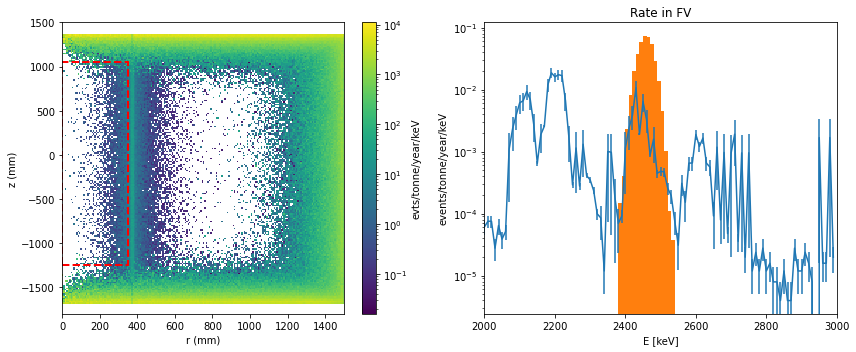

In [245]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

pcm1 = ax1.pcolormesh(*h_rz_norm.axes.edges.T, h_rz_norm.values().T, norm=matplotlib.colors.LogNorm())
ax1.add_patch(plt.Rectangle((-0, fv_z[0]), fv_r, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))
ax2.set_title(f"Events in TPC in range [{_erange[0]}, {_erange[1]}] keV")
ax1.set_xlabel("r (mm)")
ax1.set_ylabel("z (mm)")

print(f"FV considered inside Sapphire: {fv_mass} tonnes")
h_e_fv = h_rz_total[
    :bh.loc(fv_r):sum,
    bh.loc(fv_z[0]):bh.loc(fv_z[1]):sum,
    :
]
edges = h_e_fv.axes[0].edges
_binwidths = edges[1:]-edges[:-1]
values = (h_e_fv.values())/(fv_mass*_binwidths)
rate_errors = np.sqrt(h_rz_total_var.values())/(fv_mass*_binwidths)
xe136_expectation = expected_0vbb_events(0.74e28, 1)
xe136_scaling = np.full(len(xe136_sample), xe136_expectation/len(xe136_sample))

per2 = ax2.errorbar(edges[:-1], values, yerr = rate_errors)

xe136 = ax2.hist(xe136_sample, weights = xe136_scaling, bins = edges)

ax2.set_title("Rate in FV")
ax2.set_yscale('log')
ax2.set_xlabel("E [keV]")
ax2.set_ylabel("events/tonne/year/keV")
ax2.set_xlim(*_erange)

plt.colorbar(pcm1, label="evts/tonne/year/keV")
plt.colorbar(pcm2, label="evts/tonne/year/keV")
fig.tight_layout()
plt.show()

### Look at rate in R

In [39]:
h_r_slice = h_rz_norm[:, bh.loc(-1350):bh.loc(1250):bh.sum]

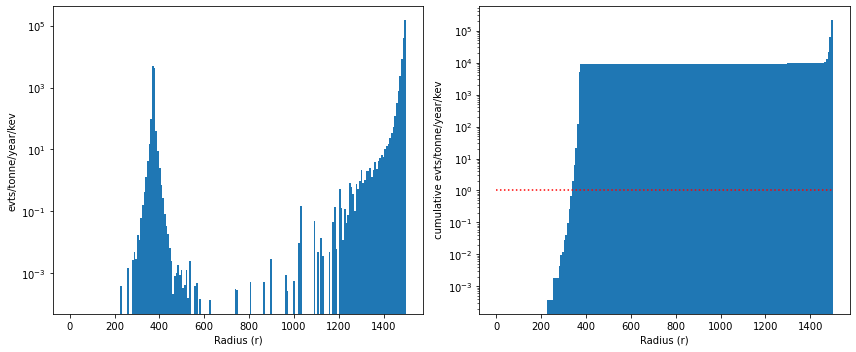

In [40]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

main_axis = h_r_slice.axes[0]
ax1.bar(main_axis.centers, h_r_slice.view()/200, width=main_axis.widths)
ax1.set_xlabel("Radius (r)")
ax1.set_ylabel("evts/tonne/year/kev")
ax1.set_yscale('log')

# Cumulative Plots
counts = h_r_slice.view()
cumulative_counts = np.cumsum(counts)

edges = h_r_slice.axes[0].edges
ax2.stairs(cumulative_counts/200, edges, fill=True)
ax2.set_yscale('log')
ax2.set_xlabel("Radius (r)")
ax2.set_ylabel(" cumulative evts/tonne/year/kev")

ax2.hlines(1, xmin=0, xmax=1500, linestyle =":", color='red')

fig.tight_layout()
plt.show()

In [41]:
h_r_slice = h_vol[:, bh.loc(-1350):bh.loc(1250):bh.sum]
print(np.sum(h_r_slice.counts()))

52.40655560527631


### Remove Sapphire Walls

In [46]:
h_rz_nosaph = h_rz_norm.copy()
r_start = h_rz_nosaph.axes[0].index(350.0)
r_end   = h_rz_nosaph.axes[0].index(435.0)
h_rz_nosaph.view(flow=True)[r_start:r_end, :] = 0
h_r_slice = h_rz_nosaph[:, bh.loc(-1350):bh.loc(1250):bh.sum]

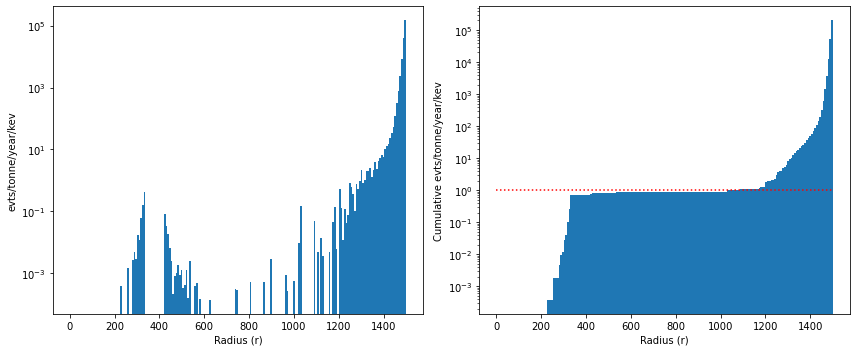

In [47]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

main_axis = h_r_slice.axes[0]
ax1.bar(main_axis.centers, h_r_slice.view()/200, width=main_axis.widths)
ax1.set_xlabel("Radius (r)")
ax1.set_ylabel("evts/tonne/year/kev")
ax1.set_yscale('log')

# Cumulative Plots
counts = h_r_slice.view()
cumulative_counts = np.cumsum(counts)

edges = h_r_slice.axes[0].edges
ax2.stairs(cumulative_counts/200, edges, fill=True)
ax2.set_yscale('log')
ax2.set_xlabel("Radius (r)")
ax2.set_ylabel("Cumulative evts/tonne/year/kev")

ax2.hlines(1, xmin=0, xmax=1500, linestyle =":", color='red')

fig.tight_layout()
plt.show()

In [49]:
h_rz_nosaph = h_vol.copy()
r_start = h_rz_nosaph.axes[0].index(350.0)
r_end   = h_rz_nosaph.axes[0].index(435.0)
h_rz_nosaph.view(flow=True)[r_start:r_end, :] = 0
h_r_slice = h_rz_nosaph[:, bh.loc(-1350):bh.loc(1250):bh.sum]
print(np.sum(h_r_slice.counts()))

50.95096352333976
